# EDA & Pre-Processing: Synthetic data (UnityEyes)

### Import Libraries

In [1]:
import os
import json
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

import random
import hashlib
import cv2
import concurrent.futures

/Users/peterthyssen/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Data set re-structuring

The synthetic data set generated by UnityEyes will first need to be imported and analyzed for any class imballances.

### 1.1 Load images & JSON description into DF

In [2]:
def load_images_and_metadata(images_folder, json_folder):
    # Initialize an empty list to store data
    data = []
    
    # Iterate through the categories in the images folder (Opened, Closed)
    for category in os.listdir(images_folder):
        category_path = os.path.join(images_folder, category)
        
        # Check if the path is a directory
        if os.path.isdir(category_path):
            
            # Iterate through the image files in the category directory
            for img_file in os.listdir(category_path):
                
                # Process only .jpg files
                if img_file.endswith('.jpg'):
                    img_path = os.path.join(category_path, img_file)
                    
                    # Open the image using PIL
                    img = Image.open(img_path)
                    
                    # Load the corresponding JSON metadata
                    json_file = img_file.replace('.jpg', '.json')
                    json_path = os.path.join(json_folder, category, json_file)
                    
                    # Initialize metadata and primary_skin_texture
                    metadata = {}
                    primary_skin_texture = ""
                    gender = "Unknown"
                    skin_color = "Unknown"
                    
                    # Check if the JSON file exists
                    if os.path.exists(json_path):
                        with open(json_path, 'r') as f:
                            # Load JSON data
                            metadata = json.load(f)
                            
                            # Extract the primary_skin_texture
                            primary_skin_texture = metadata.get("eye_region_details", {}).get("primary_skin_texture", "")
                            
                            if primary_skin_texture:
                                # Determine gender based on the first character of primary_skin_texture
                                gender = "Male" if primary_skin_texture.startswith('m') else "Female"
                                
                                # Extract the skin color part (everything after the first character)
                                skin_color = primary_skin_texture[1:]
                    
                    # Append the collected data to the list
                    data.append({
                        'category': category,          # Opened or Closed
                        'image_name': img_file,        # Image file name
                        'image_path': img_path,        # Full path to the image
                        'image': img,                  # Image object
                        'metadata': metadata,          # JSON metadata
                        'gender': gender,              # Extracted gender
                        'skin_color': skin_color       # Extracted skin color
                    })
    
    # Convert the list of dictionaries to a pandas DataFrame
    df = pd.DataFrame(data)
    return df

In [3]:
# Define the paths to the folders
images_folder = '/Users/peterthyssen/Downloads/Unity_Data_Test_Train_V3/ALL_Images'
json_folder = '/Users/peterthyssen/Downloads/Unity_Data_Test_Train_V3/ALL_JSON'

# Load images and metadata
df = load_images_and_metadata(images_folder, json_folder)

# Display the DataFrame
df.head()

,category,image_name,image_path,image,metadata,gender,skin_color
0,Opened,63.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(286.8509, 216.8656, ...",Female,02_color
1,Opened,823.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(249.7647, 223.9026, ...",Male,13_color
2,Opened,4217.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(297.0969, 200.2304, ...",Male,15_color
3,Opened,3578.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(258.1426, 221.1225, ...",Male,14_color
4,Opened,2666.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(300.1795, 246.7026, ...",Male,03_color


In [4]:
# Display the DataFrame
df.count()

category      10939
image_name    10939
image_path    10939
image         10939
metadata      10939
gender        10939
skin_color    10939
dtype: int64

In [5]:
#Check for any duplicate images

# Create an empty set to store the hashes
hashes = set()

# Initialize the count of duplicate images
duplicate_count = 0

# Iterate over the image paths in the DataFrame
for image_path in df['image_path']:
    # Read the image file as binary data
    with open(image_path, 'rb') as f:
        # Calculate the hash of the image data
        image_hash = hashlib.md5(f.read()).hexdigest()
    
    # Check if the hash is already in the set
    if image_hash in hashes:
        duplicate_count += 1
    else:
        hashes.add(image_hash)

# Print the count of duplicate images
print(f"Number of duplicate images: {duplicate_count}")

Number of duplicate images: 0


In total, 10939 images (open and closed eyes) were generated using UnityEyes.

Now, let's investigate wetjer the image classes (gender & skin color) are balanced by default.

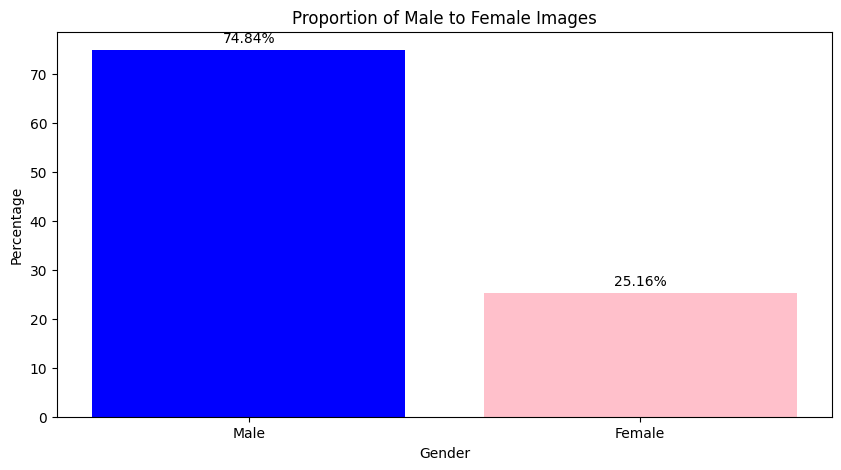

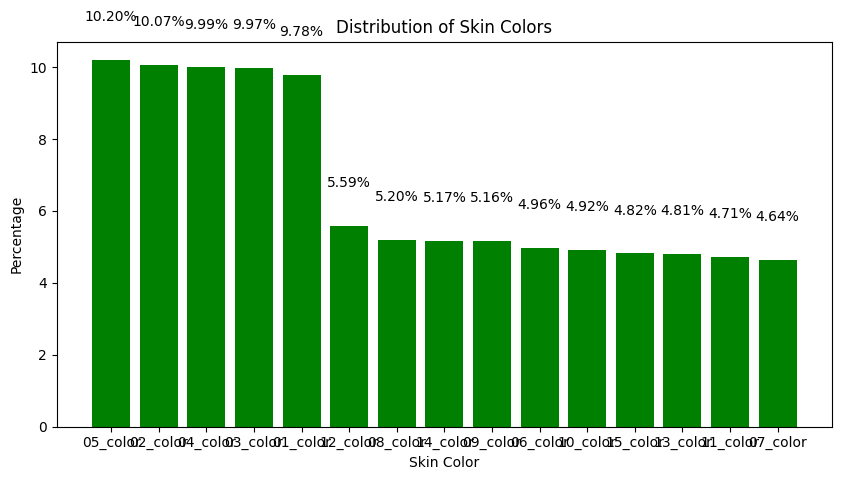

In [6]:
# Calculate the proportions of male to female images
gender_counts = df['gender'].value_counts(normalize=True) * 100  # Convert to percentage

# Calculate the distribution of skin colors
skin_color_counts = df['skin_color'].value_counts(normalize=True) * 100  # Convert to percentage

# Plot the proportion of male to female images
plt.figure(figsize=(10, 5))
plt.bar(gender_counts.index, gender_counts.values, color=['blue', 'pink'])
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.title('Proportion of Male to Female Images')
for i, v in enumerate(gender_counts.values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', va='bottom')
plt.show()

# Plot the distribution of skin colors
plt.figure(figsize=(10, 5))
plt.bar(skin_color_counts.index, skin_color_counts.values, color='green')
plt.xlabel('Skin Color')
plt.ylabel('Percentage')
plt.title('Distribution of Skin Colors')
for i, v in enumerate(skin_color_counts.values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', va='bottom')
plt.show()

We now see that by default, the images generated are generating more male (75%) than female (25%). Skin colors look to be more fairly represented ranging between highs of 10% and lows of 4%.

In order for our ML-models to not be biased towards males, we must rebalance the data set to include a 50/50 gender split

### 1.2 Create gender-balanced DF

In [7]:
# Separate the data into open and closed eye images
open_eye_images = df[df['category'] == 'Opened']
closed_eye_images = df[df['category'] == 'Closed']

# Define a function to balance gender distribution
def balance_data(df, total_samples_per_category):
    balanced_data = []

    # Ensure 50/50 gender distribution
    males = df[df['gender'] == 'Male']
    females = df[df['gender'] == 'Female']
    
    n_samples_per_gender = total_samples_per_category // 2
    male_samples = males.sample(n=n_samples_per_gender, replace=True)
    female_samples = females.sample(n=n_samples_per_gender, replace=True)
    
    # Combine male and female samples
    combined_samples = pd.concat([male_samples, female_samples])
    
    # Combine all balanced gender samples
    balanced_data = pd.concat([combined_samples])
    
    return balanced_data

In [8]:
# Balance the open eye images
balanced_open_eye_images = balance_data(open_eye_images, 2500)

# Balance the closed eye images
balanced_closed_eye_images = balance_data(closed_eye_images, 2500)

# Combine the balanced open and closed eye images into a new DataFrame
balanced_df = pd.concat([balanced_open_eye_images, balanced_closed_eye_images]).reset_index(drop=True)

# Display the new balanced DataFrame
balanced_df.head()

,category,image_name,image_path,image,metadata,gender,skin_color
0,Opened,3852.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(250.8803, 221.8264, ...",Male,06_color
1,Opened,595.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(249.2918, 235.7243, ...",Male,09_color
2,Opened,88.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(250.6145, 233.6840, ...",Male,13_color
3,Opened,3887.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(280.0909, 213.1730, ...",Male,13_color
4,Opened,483.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(259.8725, 236.8570, ...",Male,08_color


In [9]:
# Display the DataFrame
balanced_df.count()

category      5000
image_name    5000
image_path    5000
image         5000
metadata      5000
gender        5000
skin_color    5000
dtype: int64

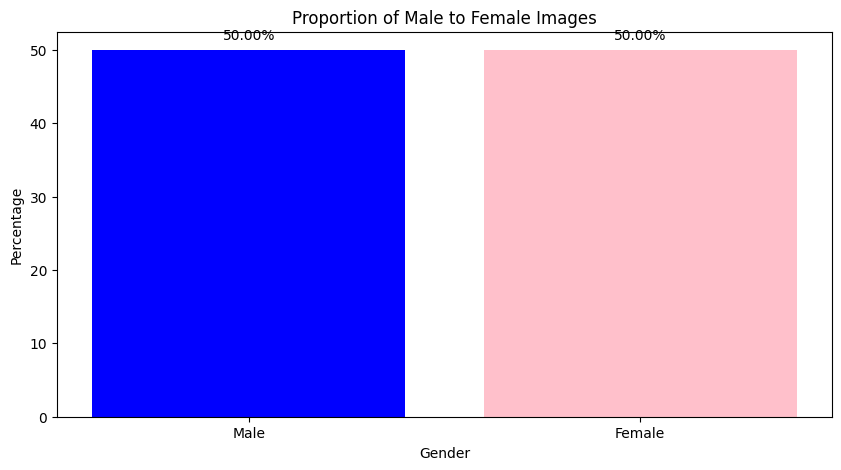

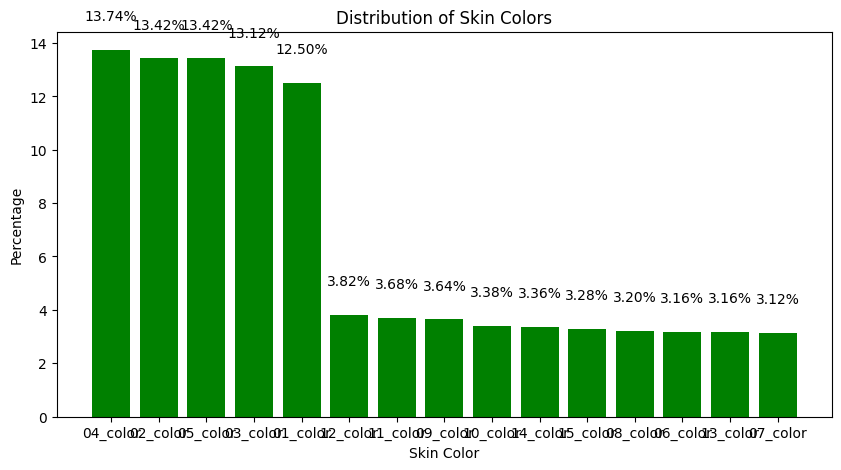

In [10]:
# Calculate the proportions of male to female images
gender_counts = balanced_df['gender'].value_counts(normalize=True) * 100  # Convert to percentage

# Calculate the distribution of skin colors
skin_color_counts = balanced_df['skin_color'].value_counts(normalize=True) * 100  # Convert to percentage

# Plot the proportion of male to female images
plt.figure(figsize=(10, 5))
plt.bar(gender_counts.index, gender_counts.values, color=['blue', 'pink'])
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.title('Proportion of Male to Female Images')
for i, v in enumerate(gender_counts.values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', va='bottom')
plt.show()

# Plot the distribution of skin colors
plt.figure(figsize=(10, 5))
plt.bar(skin_color_counts.index, skin_color_counts.values, color='green')
plt.xlabel('Skin Color')
plt.ylabel('Percentage')
plt.title('Distribution of Skin Colors')
for i, v in enumerate(skin_color_counts.values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', va='bottom')
plt.show()

In [11]:
balanced_df.head(5000)

,category,image_name,image_path,image,metadata,gender,skin_color
0,Opened,3852.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(250.8803, 221.8264, ...",Male,06_color
1,Opened,595.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(249.2918, 235.7243, ...",Male,09_color
2,Opened,88.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(250.6145, 233.6840, ...",Male,13_color
3,Opened,3887.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(280.0909, 213.1730, ...",Male,13_color
4,Opened,483.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(259.8725, 236.8570, ...",Male,08_color
...,...,...,...,...,...,...,...
4995,Closed,1270.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(253.6660, 224.0367, ...",Female,02_color
4996,Closed,1170.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(270.6397, 233.4105, ...",Female,02_color
4997,Closed,1506.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(257.5858, 209.2421, ...",Female,04_color
4998,Closed,749.jpg,/Users/peterthyssen/Downloads/Unity_Data_Test_...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,"{'interior_margin_2d': ['(259.6048, 210.5289, ...",Female,04_color


In [12]:
# Shuffle the DataFrame to ensure random distribution of genders
balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)

In [13]:
len(balanced_df)

5000

### 1.3 Export balanced data set to folders (images & JSON)

In [14]:
# Define the source folders
images_folder = '/Users/peterthyssen/Downloads/Unity_Data_Test_Train_V3/ALL_Images'
json_folder = '/Users/peterthyssen/Downloads/Unity_Data_Test_Train_V3/ALL_JSON'

# Define the target folder
balanced_folder = '/Users/peterthyssen/Downloads/Unity_Data_Test_Train_V3/ALL_Balanced'

# Create the target directories if they don't exist
os.makedirs(os.path.join(balanced_folder, 'Images', 'Opened'), exist_ok=True)
os.makedirs(os.path.join(balanced_folder, 'Images', 'Closed'), exist_ok=True)
os.makedirs(os.path.join(balanced_folder, 'JSON', 'Opened'), exist_ok=True)
os.makedirs(os.path.join(balanced_folder, 'JSON', 'Closed'), exist_ok=True)

# Function to copy and rename files
def copy_and_rename_files(row, images_folder, json_folder, balanced_folder, idx):
    # Define the source paths
    category = row['category']
    image_name = row['image_name']
    image_path = row['image_path']
    json_name = image_name.replace('.jpg', '.json')
    json_path = os.path.join(json_folder, category, json_name)
    
    # Define the new file names
    new_image_name = f"{str(idx).zfill(4)}.jpg"
    new_json_name = f"{str(idx).zfill(4)}.json"
    
    # Define the target paths
    target_image_path = os.path.join(balanced_folder, 'Images', category, new_image_name)
    target_json_path = os.path.join(balanced_folder, 'JSON', category, new_json_name)
    
    # Copy and rename the image file
    try:
        shutil.copy(image_path, target_image_path)
    except Exception as e:
        print(f"Error copying image {image_name}: {e}")
    
    # Copy and rename the JSON file
    if os.path.exists(json_path):
        try:
            shutil.copy(json_path, target_json_path)
        except Exception as e:
            print(f"Error copying JSON {json_name}: {e}")
    else:
        print(f"JSON file does not exist: {json_name}")

# Copy and rename files for each row in the balanced DataFrame
for idx, row in balanced_df.iterrows():
    copy_and_rename_files(row, images_folder, json_folder, balanced_folder, idx + 1)

# Verify the number of files copied
image_files_opened = os.listdir(os.path.join(balanced_folder, 'Images', 'Opened'))
image_files_closed = os.listdir(os.path.join(balanced_folder, 'Images', 'Closed'))
json_files_opened = os.listdir(os.path.join(balanced_folder, 'JSON', 'Opened'))
json_files_closed = os.listdir(os.path.join(balanced_folder, 'JSON', 'Closed'))

print(f"Number of image files in 'Opened': {len(image_files_opened)}")
print(f"Number of image files in 'Closed': {len(image_files_closed)}")
print(f"Number of JSON files in 'Opened': {len(json_files_opened)}")
print(f"Number of JSON files in 'Closed': {len(json_files_closed)}")
print(f"Total image files: {len(image_files_opened) + len(image_files_closed)}")
print(f"Total JSON files: {len(json_files_opened) + len(json_files_closed)}")


Number of image files in 'Opened': 2500
Number of image files in 'Closed': 2500
Number of JSON files in 'Opened': 2500
Number of JSON files in 'Closed': 2500
Total image files: 5000
Total JSON files: 5000


## 2. Exploratory Data Analysis

With a balance data set created, we can continue our EDA and data cleaning / pre-processing steps

### 2.1 Initial exploration

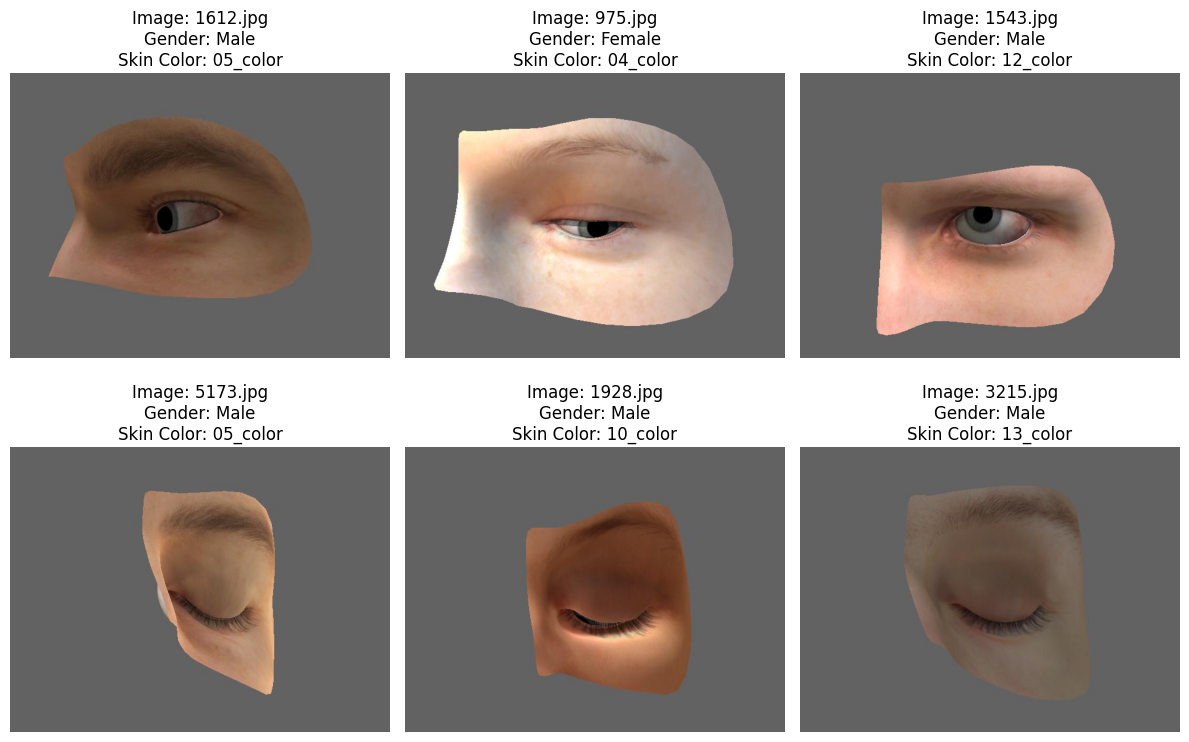

In [15]:
# Select 3 random open eye samples
open_eye_samples = balanced_open_eye_images.sample(n=3)

# Select 3 random closed eye samples
closed_eye_samples = balanced_closed_eye_images.sample(n=3)

# Create a figure with 2 rows and 3 columnss
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))

# Iterate over the open eye samples and plot them
for i, (index, row) in enumerate(open_eye_samples.iterrows()):
    # Get the image and its metadata
    image = row['image']
    image_name = row['image_name']
    gender = row['gender']
    skin_color = row['skin_color']
    
    # Get the corresponding subplot
    ax = axes[i // 3, i % 3]
    
    # Plot the image
    ax.imshow(image)
    ax.set_title(f"Image: {image_name}\nGender: {gender}\nSkin Color: {skin_color}")
    ax.axis('off')

# Iterate over the closed eye samples and plot them
for i, (index, row) in enumerate(closed_eye_samples.iterrows()):

    # Get the image and its metadata
    image = row['image']
    image_name = row['image_name']
    gender = row['gender']
    skin_color = row['skin_color']
    
    # Get the corresponding subplot
    ax = axes[(i+3) // 3, (i+3) % 3]
    
    # Plot the image
    ax.imshow(image)
    ax.set_title(f"Image: {image_name}\nGender: {gender}\nSkin Color: {skin_color}")
    ax.axis('off')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

### 2.2 Checking for corrupt images

In [16]:
corrupted_images = []

# Iterate through the dataframe
for index, row in balanced_df.iterrows():
    image_path = row['image_path']
    
    # Try to open the image file
    try:
        with Image.open(image_path) as img:
            pass
    except Exception as e:
        corrupted_images.append(image_path)

# Print the list of corrupted images
if len(corrupted_images) == 0:
    print("No corrupted images identified")
else:
    for image_path in corrupted_images:
        print(image_path)


No corrupted images identified


### 2.3 Check for dublicates

In [17]:
#Check for any duplicate images

# Create an empty set to store the hashes
hashes = set()

# Initialize the count of duplicate images
duplicate_count = 0

# Iterate over the image paths in the DataFrame
for image_path in balanced_df['image_path']:
    # Read the image file as binary data
    with open(image_path, 'rb') as f:
        # Calculate the hash of the image data
        image_hash = hashlib.md5(f.read()).hexdigest()
    
    # Check if the hash is already in the set
    if image_hash in hashes:
        duplicate_count += 1
    else:
        hashes.add(image_hash)

# Print the count of duplicate images
print(f"Number of duplicate images: {duplicate_count}")

Number of duplicate images: 1254
